<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning/Fashion_MNIST_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project overview
The objective of this project is to develop the most optimal MLP model through grid search of hyper-parameters that classifies grayscale images of fashion products into ten categories.
The project uses the Fashion-MNIST dataset, which contains \(28 * 28\)-pixel grayscale images of clothing and footwear.


This project will compare 8 deep-learning models with the following hyper-parameters:


Learning_rate,	Width,	Dropout

- 0.0001,  128,  0.0
- 0.0001,	 128,  0.1
- 0.0001,	256,	0.0
- 0.0001,	256,	0.1
- 0.001,	 128,	0.0
- 0.001,	 128,	0.1
- 0.001,	256,	0.0
- 0.001,	256,	0.1

### Business-style problem definition
Imagine an online clothing retailer that receives large numbers of product images. Each image must be assigned to a product category before it can be displayed, searched or recommended to customers.
Manually assigning these categories would be:
- Slow
- Expensive
- Inconsistent
- Difficult to scale
The machine-learning task is therefore to create an automated image-classification system that predicts the correct product category from a grayscale image.


### Machine-learning problem
This is a supervised multiclass image-classification problem.
For every image, the model predicts one of ten possible classes from 0 to 9.

### Dataset
- Fashion-MNIST contains 70,000 grayscale images.
- Dataset portion	Number of images
- Original training set	60,000
- Original test set	10,000
- Image size	(28 * 28)
- Number of classes	10


Each pixel has an intensity value between 0 and 255.

Class definitions

Label	Product category
- 0	T-shirt/top
- 1	Trouser
- 2	Pullover
- 3	Dress
- 4	Coat
- 5	Sandal
- 6	Shirt
- 7	Sneaker
- 8	Bag
- 9	Ankle boot


The dataset can be loaded directly through Keras:
from tensorflow.keras.datasets import fashion_mnist

(x_all, y_all), (x_test, y_test) = (
    fashion_mnist.load_data()
)

where x_all and y_all could be used for the training and validation parts altogether.


# Main project objective
The main objective is to build the best deep-learning model across 8 combinations of the above-mentioned hyper-parameters.



In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
import numpy as np

In [ ]:
(x_all, y_all), (x_test, y_test) = (fashion_mnist.load_data())
print(x_all.shape)
print(x_test.shape)
print(y_all.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [ ]:
# First, we create a random index array and extract the training and validation
# parts out of x_all and y_all and normalize them

SEED = 42
rng = np.random.default_rng(SEED)

indices = rng.permutation(len(x_all))

val_indices = indices[:10000]
train_indices = indices[10000:]

x_val = x_all[val_indices].astype(np.float32)/ 255.0
y_val = y_all[val_indices]

x_train = x_all[train_indices].astype(np.float32)/ 255.0
y_train = y_all[train_indices]

x_test = x_test.astype(np.float32)/ 255.0


In [ ]:
def build_model(widths, initializer, dropouts):

  model = Sequential([
      Input(shape = (28, 28)),
      Flatten(),

      Dense(widths, activation = 'relu', kernel_initializer = initializer),
      BatchNormalization(),
      Dropout(dropouts),

      Dense(int(widths/2), activation = 'relu', kernel_initializer = initializer),
      BatchNormalization(),
      Dropout(dropouts),

      Dense(10, activation = 'softmax')])

  model.compile(
      optimizer = Adam(learning_rate = 0.0001),
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
  )
  return model

In [ ]:
import itertools

initializers = ['he_normal', 'glorot_normal']
widths = [128,  256]
dropouts = [0.0, 0.1]
hyper_parameters = list(itertools.product(widths, initializers, dropouts))

print(hyper_parameters)

[(128, 'he_normal', 0.0), (128, 'he_normal', 0.1), (128, 'glorot_normal', 0.0), (128, 'glorot_normal', 0.1), (256, 'he_normal', 0.0), (256, 'he_normal', 0.1), (256, 'glorot_normal', 0.0), (256, 'glorot_normal', 0.1)]


Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6745 - loss: 0.9875 - val_accuracy: 0.7387 - val_loss: 0.9385
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8087 - loss: 0.5767 - val_accuracy: 0.8154 - val_loss: 0.5670
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8339 - loss: 0.4884 - val_accuracy: 0.8336 - val_loss: 0.4723
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8485 - loss: 0.4400 - val_accuracy: 0.8489 - val_loss: 0.4335
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8581 - loss: 0.4079 - val_accuracy: 0.8546 - val_loss: 0.4136
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8654 - loss: 0.3840 - val_accuracy: 0.8594 - val_loss: 0.3971
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8718 - loss: 0.3648 - val_accuracy: 0.8628 - val_loss: 0.3831
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8770 - loss: 0.3489 - val_accuracy

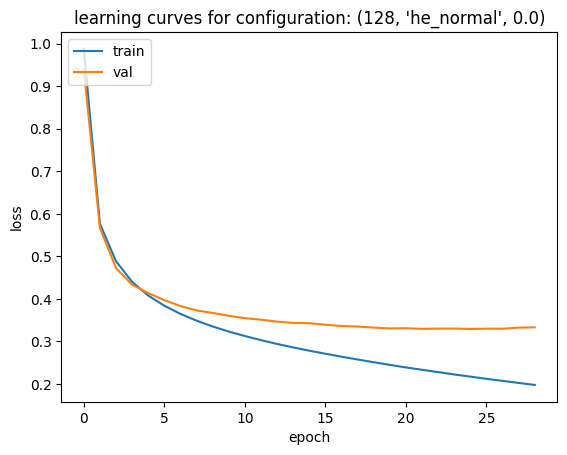

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6411 - loss: 1.1062 - val_accuracy: 0.7702 - val_loss: 0.8907
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7869 - loss: 0.6546 - val_accuracy: 0.8121 - val_loss: 0.5725
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8142 - loss: 0.5570 - val_accuracy: 0.8322 - val_loss: 0.4851
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8299 - loss: 0.5048 - val_accuracy: 0.8431 - val_loss: 0.4522
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8401 - loss: 0.4690 - val_accuracy: 0.8485 - val_loss: 0.4228
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8456 - loss: 0.4448 - val_accuracy: 0.8538 - val_loss: 0.4089
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8518 - loss: 0.4241 - val_accuracy: 0.8596 - val_loss: 0.3907
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8565 - loss: 0.4071 - val_accur

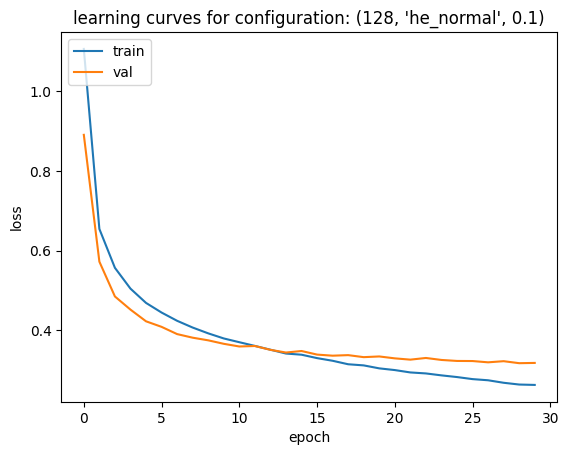

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6839 - loss: 0.9570 - val_accuracy: 0.7454 - val_loss: 0.9682
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8128 - loss: 0.5603 - val_accuracy: 0.8213 - val_loss: 0.5573
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8381 - loss: 0.4751 - val_accuracy: 0.8403 - val_loss: 0.4624
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8517 - loss: 0.4288 - val_accuracy: 0.8497 - val_loss: 0.4266
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8616 - loss: 0.3979 - val_accuracy: 0.8562 - val_loss: 0.4072
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8682 - loss: 0.3747 - val_accuracy: 0.8612 - val_loss: 0.3904
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8751 - loss: 0.3560 - val_accuracy: 0.8641 - val_loss: 0.3796
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8798 - loss: 0.3406 - val_accuracy: 

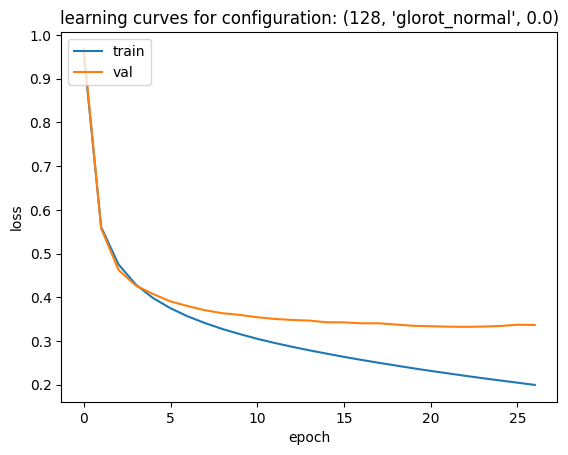

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6521 - loss: 1.0717 - val_accuracy: 0.7746 - val_loss: 0.9176
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7912 - loss: 0.6383 - val_accuracy: 0.8188 - val_loss: 0.5611
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8184 - loss: 0.5436 - val_accuracy: 0.8384 - val_loss: 0.4723
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8328 - loss: 0.4927 - val_accuracy: 0.8450 - val_loss: 0.4422
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8425 - loss: 0.4582 - val_accuracy: 0.8532 - val_loss: 0.4137
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8496 - loss: 0.4345 - val_accuracy: 0.8591 - val_loss: 0.3992
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8543 - loss: 0.4149 - val_accuracy: 0.8624 - val_loss: 0.3837
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8601 - loss: 0.3983 - val_accura

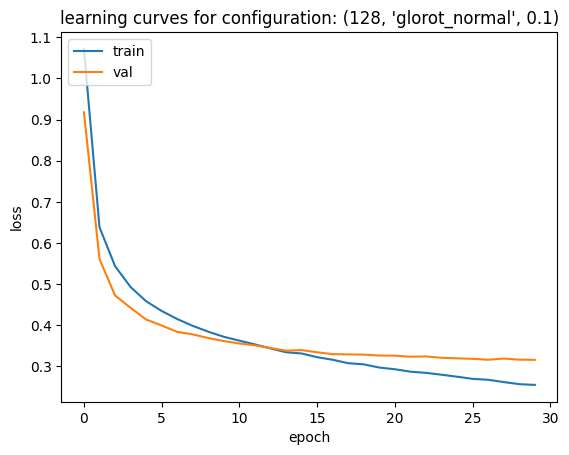

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7148 - loss: 0.8678 - val_accuracy: 0.8005 - val_loss: 0.7566
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8363 - loss: 0.4798 - val_accuracy: 0.8406 - val_loss: 0.4702
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8568 - loss: 0.4121 - val_accuracy: 0.8556 - val_loss: 0.4065
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8694 - loss: 0.3736 - val_accuracy: 0.8650 - val_loss: 0.3798
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8774 - loss: 0.3468 - val_accuracy: 0.8679 - val_loss: 0.3647
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8853 - loss: 0.3266 - val_accuracy: 0.8719 - val_loss: 0.3537
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8912 - loss: 0.3092 - val_accuracy: 0.8738 - val_loss: 0.3454
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8970 - loss: 0.2941 - val_accu

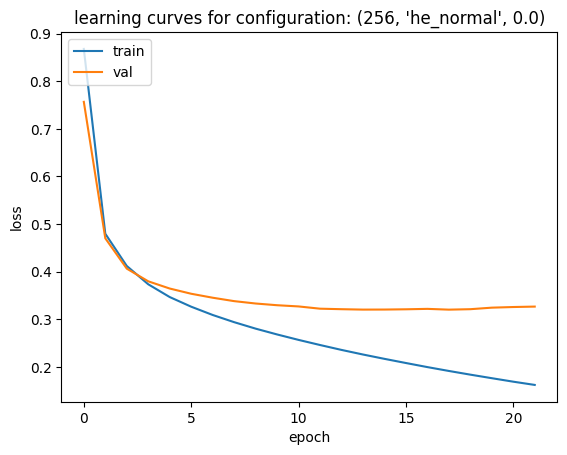

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7012 - loss: 0.8849 - val_accuracy: 0.7937 - val_loss: 0.7475
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8178 - loss: 0.5281 - val_accuracy: 0.8398 - val_loss: 0.4726
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8396 - loss: 0.4598 - val_accuracy: 0.8525 - val_loss: 0.4161
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8519 - loss: 0.4211 - val_accuracy: 0.8622 - val_loss: 0.3839
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8600 - loss: 0.3943 - val_accuracy: 0.8661 - val_loss: 0.3735
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8678 - loss: 0.3749 - val_accuracy: 0.8712 - val_loss: 0.3589
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8723 - loss: 0.3561 - val_accuracy: 0.8729 - val_loss: 0.3507
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8772 - loss: 0.3407 - val_accu

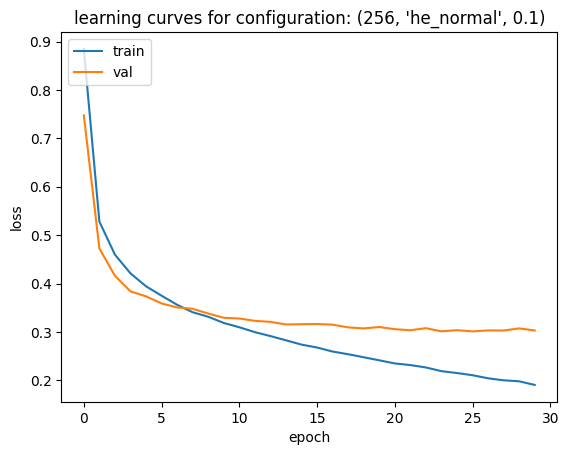

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7298 - loss: 0.8192 - val_accuracy: 0.8035 - val_loss: 0.8036
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8420 - loss: 0.4610 - val_accuracy: 0.8424 - val_loss: 0.4643
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8618 - loss: 0.3971 - val_accuracy: 0.8593 - val_loss: 0.3956
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8732 - loss: 0.3606 - val_accuracy: 0.8663 - val_loss: 0.3716
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8811 - loss: 0.3348 - val_accuracy: 0.8704 - val_loss: 0.3565
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8890 - loss: 0.3144 - val_accuracy: 0.8744 - val_loss: 0.3465
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8953 - loss: 0.2973 - val_accuracy: 0.8779 - val_loss: 0.3399
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9009 - loss: 0.2821 - val_accu

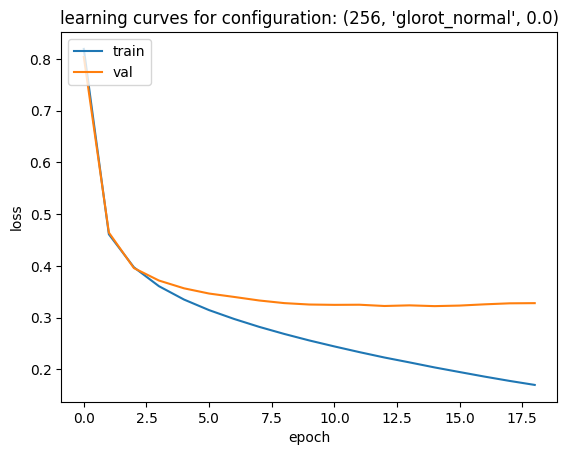

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7149 - loss: 0.8401 - val_accuracy: 0.7981 - val_loss: 0.7895
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8240 - loss: 0.5088 - val_accuracy: 0.8429 - val_loss: 0.4684
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8455 - loss: 0.4447 - val_accuracy: 0.8558 - val_loss: 0.4053
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8557 - loss: 0.4077 - val_accuracy: 0.8659 - val_loss: 0.3753
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8643 - loss: 0.3819 - val_accuracy: 0.8701 - val_loss: 0.3630
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8710 - loss: 0.3626 - val_accuracy: 0.8715 - val_loss: 0.3511
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8770 - loss: 0.3445 - val_accuracy: 0.8740 - val_loss: 0.3434
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8811 - loss: 0.3291 - val_accu

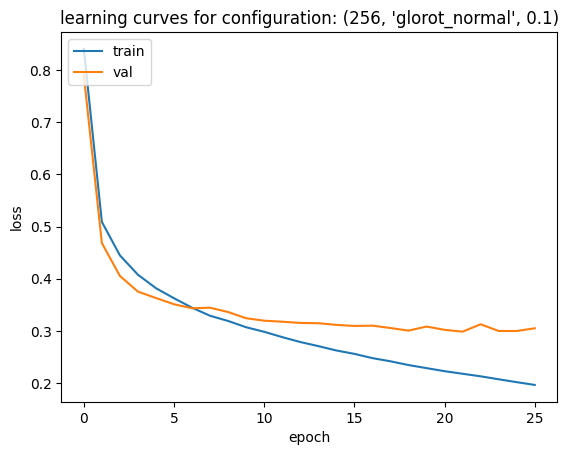

In [ ]:
import time
from keras.backend import clear_session
from keras.utils import set_random_seed

SEED = 42

training_times = []
experiments = []
configurations = []
best_epochs = []
best_accuracies = []
best_losses = []

for experiment, (width, initializer, dropout) in enumerate(hyper_parameters, start = 1):

  clear_session()
  set_random_seed(SEED)

  configurations.append((width, initializer, dropout))
  experiments.append(experiment)



  model = build_model(width, initializer, dropout)

  ES = EarlyStopping(
    monitor = 'val_loss',
    patience = 4,
    verbose = 1,
    restore_best_weights = True,
    mode = 'min' )


  start_time = time.time()
  HISTORY = model.fit(x_train, y_train,
          epochs = 30,
          validation_data = (x_val, y_val),
          batch_size = 256,
          verbose = 1,
          callbacks = [ES])


  training_times.append(time.time() - start_time)
  print(time.time() - start_time)


  best_epochs.append(np.argmax(HISTORY.history['val_accuracy']))
  best_accuracies.append(np.max(HISTORY.history['val_accuracy']))
  best_losses.append(np.min(HISTORY.history['val_loss']))


  plt.plot(HISTORY.history['loss'])
  plt.plot(HISTORY.history['val_loss'])
  plt.title(f'learning curves for configuration: {(width, initializer, dropout)}')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train', 'val'], loc='upper left')
  plt.show()

  '''plt.plot(HISTORY.history['accuracy'])
  plt.plot(HISTORY.history['val_accuracy'])
  plt.title(f'accuracy curves for configuration: {(width, learning_rate, dropout)}')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'val'], loc='upper left')
  plt.show()'''

In [ ]:
training_times

In [ ]:
dictionary = {
    'experiments' : experiments,
    'best_accuracies' : best_accuracies,
    'best_losses' : best_losses,
    'training_times' : training_times,
    'configurations' : configurations,
    'best_epochs' : best_epochs
    }



In [ ]:
import pandas as pd

final_result = pd.DataFrame(dictionary)
final_result

,experiments,best_accuracies,best_losses,training_times,configurations,best_epochs
0,1,0.8818,0.329256,61.445716,"(128, he_normal, 0.0)",21
1,2,0.8861,0.317725,69.199639,"(128, he_normal, 0.1)",26
2,3,0.8813,0.332106,55.816064,"(128, glorot_normal, 0.0)",22
3,4,0.8871,0.315740,70.943365,"(128, glorot_normal, 0.1)",29
4,5,0.8861,0.320359,76.674201,"(256, he_normal, 0.0)",19
5,6,0.8941,0.301143,106.433196,"(256, he_normal, 0.1)",29
6,7,0.8842,0.322133,65.147863,"(256, glorot_normal, 0.0)",18
7,8,0.8902,0.298603,100.199362,"(256, glorot_normal, 0.1)",21
